# 08 — Transfer: switchable boundary conditions (Dirichlet / PML)

This notebook section standardizes the setup so we can **choose boundary conditions**:
- **Dirichlet** (hard wall, u=0 at the boundary)
- **PML** (absorbing layer via complex stretching)

We’ll configure the grid and wavenumber ranges, create a tiny discretization adapter
that the dataset builders expect (`disc.assemble(grid, k)`), and then build small datasets
to sanity-check shapes and boundary behavior.


In [29]:
#%load_ext autoreload
#%autoreload 2

import torch
import numpy as np
from dataclasses import dataclass

from src import GridSpec, GMRESOptions
from src.datasets import build_direct_map, build_freq_transfer
from src.visualisation import plot_residuals
from src.training import train_model, show_example
from src.models import SimpleFNO, LocalCNN

# Operator entrypoints
from src.operators import PMLConfig, helmholtz_operator


In [28]:
# Core API
import numpy as np
from functools import partial


from src.solvers import direct_solve  # your existing numerical oracle


## Global configuration

Define the domain, wavenumber ranges for **low** and **high** frequency bands,
and the dataset sizes. Keep these centralized so experiments are easy to change.


In [30]:
# Grid
grid = GridSpec(dims=2, shape=(60, 60), lengths=(1.0, 1.0))
nx, ny = grid.shape
hx = grid.lengths[0] / (nx - 1)
hy = grid.lengths[1] / (ny - 1)

# Wavenumber ranges
K_LOW_RANGE  = (10.0, 30.0)
K_HIGH_RANGE = (40.0, 90.0)
k_high_max   = float(max(K_HIGH_RANGE))

# Dataset sizes
N_SAMPLES = 100  # increase later to 200–500 for stronger training

# (Only used if/when we run GMRES; harmless to keep)
gmres_opts = GMRESOptions(tol=1e-6, restart=None, maxiter=None)


## Choose boundary condition mode

Set `BC_MODE` to `"dirichlet"` or `"pml"`.  
If `"pml"`, we enable a PML collar with thickness and damping chosen relative to `k` and `h`.


In [31]:
# Choose: "dirichlet" or "pml"
BC_MODE = "pml"   # <- change to "dirichlet" for hard-wall boundaries

# PML parameters (only used if BC_MODE == "pml")
# Thickness: ~10–14 cells or about 12% of the smallest side is a good start.
t_cells   = max(10, int(0.12 * min(nx, ny)))
# Damping: scale with k/h; increase if you see edge reflections, decrease if over-damped.
sigma_max = 0.8 * k_high_max / min(hx, hy)
# Polynomial order for ramp; m=3 is a robust default.
pml_cfg   = PMLConfig(thickness=t_cells, m=3, sigma_max=sigma_max) if BC_MODE == "pml" else None

print("BC_MODE =", BC_MODE)
if pml_cfg is not None:
    print("Using PML:", pml_cfg)


BC_MODE = pml
Using PML: PMLConfig(thickness=10, m=3, sigma_max=4248.0)


## Discretization adapter

Our dataset builders expect an object with a method `assemble(grid, k)`.
We provide a tiny adapter that calls `helmholtz_operator(...)` under the hood.

- If `BC_MODE=="dirichlet"`, we pass `pml=None`.
- If `BC_MODE=="pml"`, we pass `pml=pml_cfg`.


In [32]:
@dataclass
class DiscAdapter:
    dtype: np.dtype = np.complex128
    pml: PMLConfig | None = None

    def assemble(self, grid, k: float):
        return helmholtz_operator(
            shape=grid.shape,
            lengths=grid.lengths,
            k=float(k),
            dtype=self.dtype,
            pml=self.pml,
        )

disc = DiscAdapter(dtype=np.complex128, pml=pml_cfg)


## Sanity datasets

We first build a tiny dataset (`mini_A`) to verify shapes and the
wiring. Then we build the actual datasets for:
- **Direct map**: `(f, k) → u`
- **Frequency transfer**: `(u_low, k_high) → u_high`


In [ ]:
# Tiny sanity dataset (2 samples)
mini_A = build_direct_map(
    n=2,
    grid=grid,
    disc=disc,               # uses our adapter → Dirichlet or PML depending on BC_MODE
    k_range=K_LOW_RANGE,
)

# Full datasets
data_A = build_direct_map(
    n=N_SAMPLES,
    grid=grid,
    disc=disc,
    k_range=K_HIGH_RANGE,
)

data_B = build_freq_transfer(
    n=N_SAMPLES,
    grid=grid,
    disc=disc,
    k_low_range=K_LOW_RANGE,
    k_high_range=K_HIGH_RANGE,
)

print("mini_A:", mini_A["x"].shape, mini_A["y"].shape)
print("data_A:", data_A["x"].shape, data_A["y"].shape)
print("data_B:", data_B["x"].shape, data_B["y"].shape)


mini_A: (2, 3, 60, 60) (2, 2, 60, 60)
data_A: (100, 3, 60, 60) (100, 2, 60, 60)
data_B: (100, 3, 60, 60) (100, 2, 60, 60)


## Optional: boundary sanity check

For PML, we expect the average magnitude in the PML collar to be **much smaller**
than in the interior. See the check below. 


In [23]:

def as_abs_grid(u, shape: tuple[int, int]) -> np.ndarray:
    """
    Convert various encodings of a complex field to a |u| grid of shape (ny, nx).

    Accepts:
      - flat complex:           (N,), dtype complex
      - flat stacked Re/Im:     (2N,) as [Re... Im...]
      - 2×N channels:           (2, N) or (N, 2)
      - 2×ny×nx (channels first) or ny×nx×2 (channels last)
    """
    nx, ny = shape
    N = nx * ny

    # torch → numpy if needed
    if hasattr(u, "detach"):
        u = u.detach().cpu().numpy()
    u = np.asarray(u)

    # 1) already complex, flat
    if np.iscomplexobj(u) and u.ndim == 1 and u.size == N:
        return np.abs(u).reshape(ny, nx)

    # 2) flat stacked Re/Im
    if u.ndim == 1 and u.size == 2 * N:
        re = u[:N].reshape(ny, nx)
        im = u[N:].reshape(ny, nx)
        return np.sqrt(re**2 + im**2)

    # 3) 2 × N or N × 2
    if u.ndim == 2:
        if u.shape == (2, N):
            re = u[0].reshape(ny, nx)
            im = u[1].reshape(ny, nx)
            return np.sqrt(re**2 + im**2)
        if u.shape == (N, 2):
            re = u[:, 0].reshape(ny, nx)
            im = u[:, 1].reshape(ny, nx)
            return np.sqrt(re**2 + im**2)

    # 4) 2 × ny × nx (channels first) or ny × nx × 2 (channels last)
    if u.ndim == 3:
        if u.shape == (2, ny, nx):
            re, im = u[0], u[1]
            return np.sqrt(re**2 + im**2)
        if u.shape == (ny, nx, 2):
            re, im = u[..., 0], u[..., 1]
            return np.sqrt(re**2 + im**2)

    raise ValueError(f"Unrecognized field shape {u.shape} for grid {shape}.")

In [24]:
def pml_decay_report_any(u, shape: tuple[int, int], t: int):
    """
    Wrapper that converts u→|u| grid with `as_abs_grid` and reports interior vs collar means.
    """
    U = as_abs_grid(u, shape)  # (ny, nx)
    if t <= 0 or 2 * t >= min(shape):
        print("PML check: thickness too small/large for this grid.")
        return
    inner = U[t:-t, t:-t]
    collar = U.copy()
    collar[t:-t, t:-t] = 0.0
    m_inner = float(np.mean(inner))
    collar_vals = collar[np.nonzero(collar)]
    m_collar = float(np.mean(collar_vals)) if collar_vals.size else 0.0
    ratio = m_collar / (m_inner + 1e-14)
    print(f"PML check — ⟨|u|⟩ interior: {m_inner:.3e} | ⟨|u|⟩ collar: {m_collar:.3e} | ratio: {ratio:.3e}")

In [25]:
if BC_MODE == "pml":
    u_example = mini_A["y"][0]   # whatever layout it uses
    pml_decay_report_any(u_example, shape=grid.shape, t=pml_cfg.thickness)


PML check — ⟨|u|⟩ interior: 7.755e-11 | ⟨|u|⟩ collar: 7.070e-08 | ratio: 9.115e+02


Text(0.5, 1.0, '|u| magnitude')

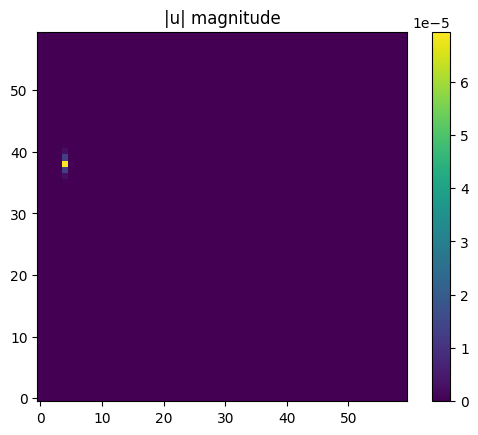

In [26]:
import matplotlib.pyplot as plt
U = as_abs_grid(u_example, grid.shape)
plt.imshow(U, origin="lower"); plt.colorbar(); plt.title("|u| magnitude")


## Next steps

- Train/evaluate your direct and transfer models using `data_A` and `data_B`.
- If you see edge reflections with PML:
  - Increase `thickness` by +2–4 cells, or
  - Increase `sigma_max` (e.g., ×1.5) while keeping `m=3`.
- If over-damped (solution looks too small overall), reduce `sigma_max` a bit.
